# TP2 - Módulo 2
## Notebook 05 - Validación del Modelo

**Objetivo:** Evaluar en profundidad el modelo final con métricas de clasificación, matriz de confusión, curvas ROC/PR y análisis de errores.

In [1]:
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid')

In [2]:
# Cargar modelo y datos
model     = joblib.load('../models/xgb_model.joblib')
threshold = joblib.load('../models/threshold.joblib')

X_train = pd.read_parquet('../data/processed/X_train.parquet')
X_test  = pd.read_parquet('../data/processed/X_test.parquet')
y_train = pd.read_csv('../data/processed/y_train.csv', index_col=0).squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv', index_col=0).squeeze()

print(f'Modelo cargado | Umbral: {threshold:.2f}')

Modelo cargado | Umbral: 0.48


## 1. Probabilidades y predicciones

In [3]:
y_train_proba = model.predict_proba(X_train)[:, 1]
y_test_proba  = model.predict_proba(X_test)[:, 1]

y_train_pred = (y_train_proba >= threshold).astype(int)
y_test_pred  = (y_test_proba  >= threshold).astype(int)

## 2. Classification Report completo

In [4]:
print(f'=== TRAIN (umbral = {threshold:.2f}) ===')
print(classification_report(y_train, y_train_pred, target_names=['No fumador', 'Fumador']))

print(f'=== TEST (umbral = {threshold:.2f}) ===')
print(classification_report(y_test, y_test_pred, target_names=['No fumador', 'Fumador']))

f1_final = f1_score(y_test, y_test_pred, pos_label=1)
print(f'>>> F1-Score final (clase 1, test): {f1_final:.4f}')

=== TRAIN (umbral = 0.48) ===
              precision    recall  f1-score   support

  No fumador       0.97      0.80      0.88     25337
     Fumador       0.74      0.96      0.84     14663

    accuracy                           0.86     40000
   macro avg       0.86      0.88      0.86     40000
weighted avg       0.89      0.86      0.86     40000

=== TEST (umbral = 0.48) ===
              precision    recall  f1-score   support

  No fumador       0.90      0.71      0.79      6334
     Fumador       0.63      0.87      0.73      3666

    accuracy                           0.76     10000
   macro avg       0.77      0.79      0.76     10000
weighted avg       0.80      0.76      0.77     10000

>>> F1-Score final (clase 1, test): 0.7297


## 3. Matriz de Confusión

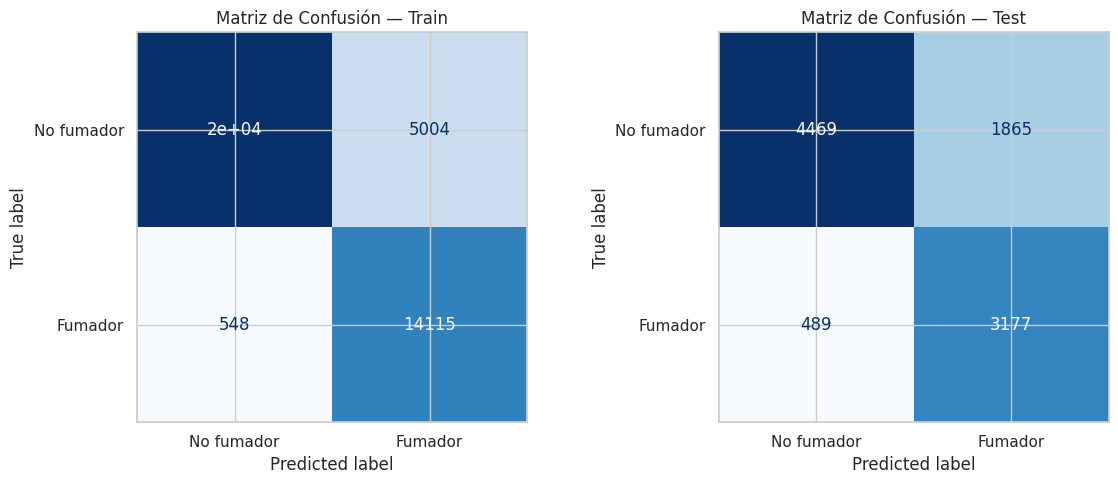

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (y_true, y_pred, titulo) in zip(axes, [
    (y_train, y_train_pred, 'Train'),
    (y_test,  y_test_pred,  'Test')
]):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No fumador', 'Fumador'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Matriz de Confusión — {titulo}')

plt.tight_layout()
plt.show()

## 4. Curva ROC

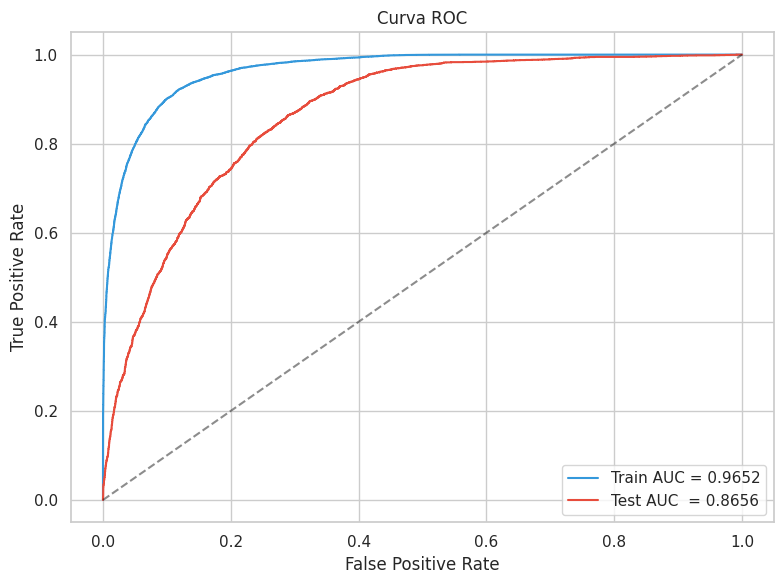

In [6]:
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_test,  tpr_test,  _ = roc_curve(y_test,  y_test_proba)

auc_train = roc_auc_score(y_train, y_train_proba)
auc_test  = roc_auc_score(y_test,  y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f'Train AUC = {auc_train:.4f}', color='#3498db')
plt.plot(fpr_test,  tpr_test,  label=f'Test AUC  = {auc_test:.4f}',  color='#e74c3c')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Curva Precisión-Recall

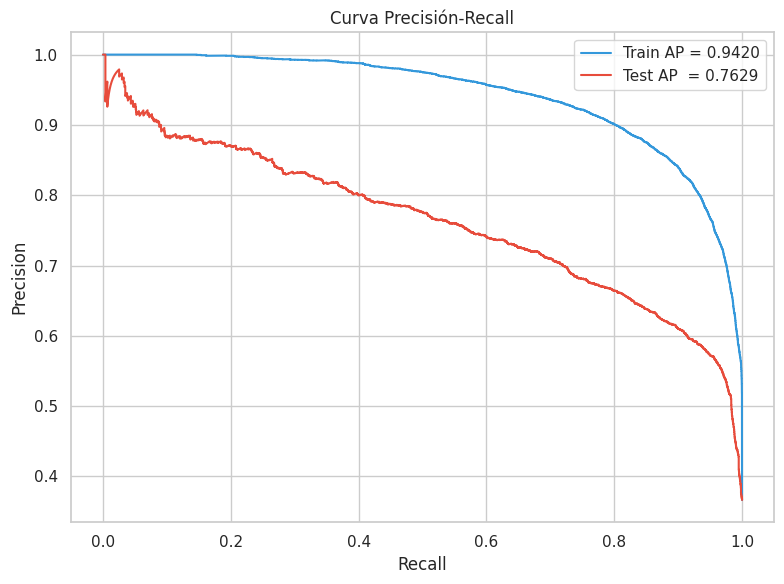

In [7]:
prec_train, rec_train, _ = precision_recall_curve(y_train, y_train_proba)
prec_test,  rec_test,  _ = precision_recall_curve(y_test,  y_test_proba)

ap_train = average_precision_score(y_train, y_train_proba)
ap_test  = average_precision_score(y_test,  y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(rec_train, prec_train, label=f'Train AP = {ap_train:.4f}', color='#3498db')
plt.plot(rec_test,  prec_test,  label=f'Test AP  = {ap_test:.4f}',  color='#e74c3c')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precisión-Recall')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Distribución de probabilidades predichas

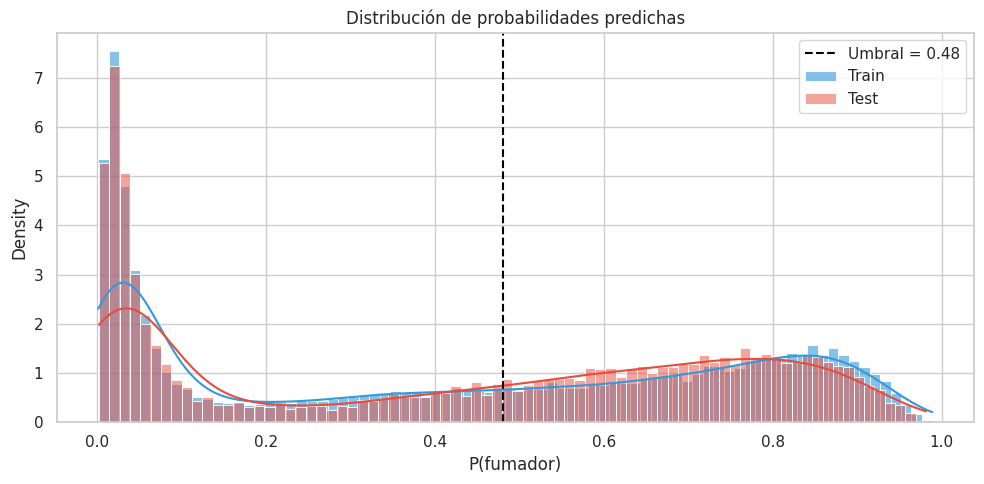

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(y_train_proba, bins=80, kde=True, label='Train', stat='density', alpha=0.6, color='#3498db')
sns.histplot(y_test_proba,  bins=80, kde=True, label='Test',  stat='density', alpha=0.5, color='#e74c3c')
plt.axvline(threshold, color='black', linestyle='--', linewidth=1.5, label=f'Umbral = {threshold:.2f}')
plt.title('Distribución de probabilidades predichas')
plt.xlabel('P(fumador)')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Resumen de métricas

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

resumen = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision (clase 1)', 'Recall (clase 1)',
                'F1 (clase 1)', 'ROC-AUC'],
    'Train': [
        round(accuracy_score(y_train, y_train_pred), 4),
        round(precision_score(y_train, y_train_pred, pos_label=1), 4),
        round(recall_score(y_train, y_train_pred, pos_label=1), 4),
        round(f1_score(y_train, y_train_pred, pos_label=1), 4),
        round(auc_train, 4)
    ],
    'Test': [
        round(accuracy_score(y_test, y_test_pred), 4),
        round(precision_score(y_test, y_test_pred, pos_label=1), 4),
        round(recall_score(y_test, y_test_pred, pos_label=1), 4),
        round(f1_score(y_test, y_test_pred, pos_label=1), 4),
        round(auc_test, 4)
    ]
})

print(resumen.to_string(index=False))
print(f'\n>>> MÉTRICA OBJETIVO — F1-Score (clase 1, test): {f1_final:.4f}')

            Métrica  Train   Test
           Accuracy 0.8612 0.7646
Precision (clase 1) 0.7383 0.6301
   Recall (clase 1) 0.9626 0.8666
       F1 (clase 1) 0.8357 0.7297
            ROC-AUC 0.9652 0.8656

>>> MÉTRICA OBJETIVO — F1-Score (clase 1, test): 0.7297
